In [9]:
import numpy as np
import seaborn as sns
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
from datetime import datetime

In [10]:
# force 'normal' text style for math text
mpl.rcParams['mathtext.default'] = 'regular'

# set global seaborn params
sns.set("paper", "ticks", color_codes=True, palette='colorblind')

## Loading Data

In [11]:
ts = pd.read_csv('MOD-00681-2-26data.csv')
COLS_TO_INCLUDE = ['timestamp_local','bin0','bin1','bin2','bin3','bin4','bin5','pm25','co','o3','no','no2','rh','temp']
ts = ts[COLS_TO_INCLUDE]
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-29T08:41:45Z,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1112.629,38.829,4.079,10.497,94.9,6.1
1,2025-12-29T08:40:49Z,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1128.639,39.246,4.044,10.500,94.9,6.1
2,2025-12-29T08:39:47Z,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1119.608,39.246,4.079,10.500,94.9,6.1
3,2025-12-29T08:38:45Z,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1114.682,39.246,3.813,10.500,94.9,6.1
4,2025-12-29T08:37:48Z,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1119.197,39.663,3.811,10.500,94.9,6.1


In [12]:
ts['timestamp_local'] = pd.to_datetime(ts['timestamp_local'],format="%Y-%m-%dT%H:%M:%SZ") #convert timestamp column to pandas timestamp format
ts.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
0,2025-12-29 08:41:45,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1112.629,38.829,4.079,10.497,94.9,6.1
1,2025-12-29 08:40:49,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1128.639,39.246,4.044,10.500,94.9,6.1
2,2025-12-29 08:39:47,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1119.608,39.246,4.079,10.500,94.9,6.1
3,2025-12-29 08:38:45,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1114.682,39.246,3.813,10.500,94.9,6.1
4,2025-12-29 08:37:48,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1119.197,39.663,3.811,10.500,94.9,6.1


## Full Timeseries Plot

In [13]:
#taking daily average of ts. round to floor of the day
ts_day = ts.groupby(ts['timestamp_local'].dt.floor('d')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_day = ts_day.set_index('timestamp_local')
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-03-31,27.723267,4.139546,1.289750,0.383533,0.509788,0.419442,9.351308,952.474354,47.106583,2.605217,18.544450,85.732917,15.907917
2025-04-01,6.420656,0.606907,0.177283,0.040526,0.044531,0.028106,2.410631,685.405546,57.874160,2.299495,6.481710,46.940139,10.829306
2025-04-02,6.055686,0.675951,0.362896,0.123617,0.162234,0.131021,4.447065,820.371710,59.179052,2.111319,13.179242,42.343403,7.552986
2025-04-03,23.592510,2.622632,0.911997,0.319486,0.469449,0.396394,11.514749,941.775951,44.321283,2.157639,15.851640,77.506389,15.239444
2025-04-04,5.453719,0.407057,0.156908,0.046833,0.063069,0.046655,3.718522,747.718203,50.918904,2.099643,9.626278,44.732569,20.029653


In [14]:
ts_day['pm25_c'] = 3.491 + 0.576*ts_day['pm25'] - 0.047*ts_day['rh'] + 0.070*ts_day['temp']
ts_day.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-03-31,27.723267,4.139546,1.289750,0.383533,0.509788,0.419442,9.351308,952.474354,47.106583,2.605217,18.544450,85.732917,15.907917,5.961461
2025-04-01,6.420656,0.606907,0.177283,0.040526,0.044531,0.028106,2.410631,685.405546,57.874160,2.299495,6.481710,46.940139,10.829306,3.431388
2025-04-02,6.055686,0.675951,0.362896,0.123617,0.162234,0.131021,4.447065,820.371710,59.179052,2.111319,13.179242,42.343403,7.552986,4.591078
2025-04-03,23.592510,2.622632,0.911997,0.319486,0.469449,0.396394,11.514749,941.775951,44.321283,2.157639,15.851640,77.506389,15.239444,7.547456
2025-04-04,5.453719,0.407057,0.156908,0.046833,0.063069,0.046655,3.718522,747.718203,50.918904,2.099643,9.626278,44.732569,20.029653,4.932514


<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-217/2170964161.py:47: SyntaxWarning: invalid escape sequence '\m'
  ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}]",fontsize=14)


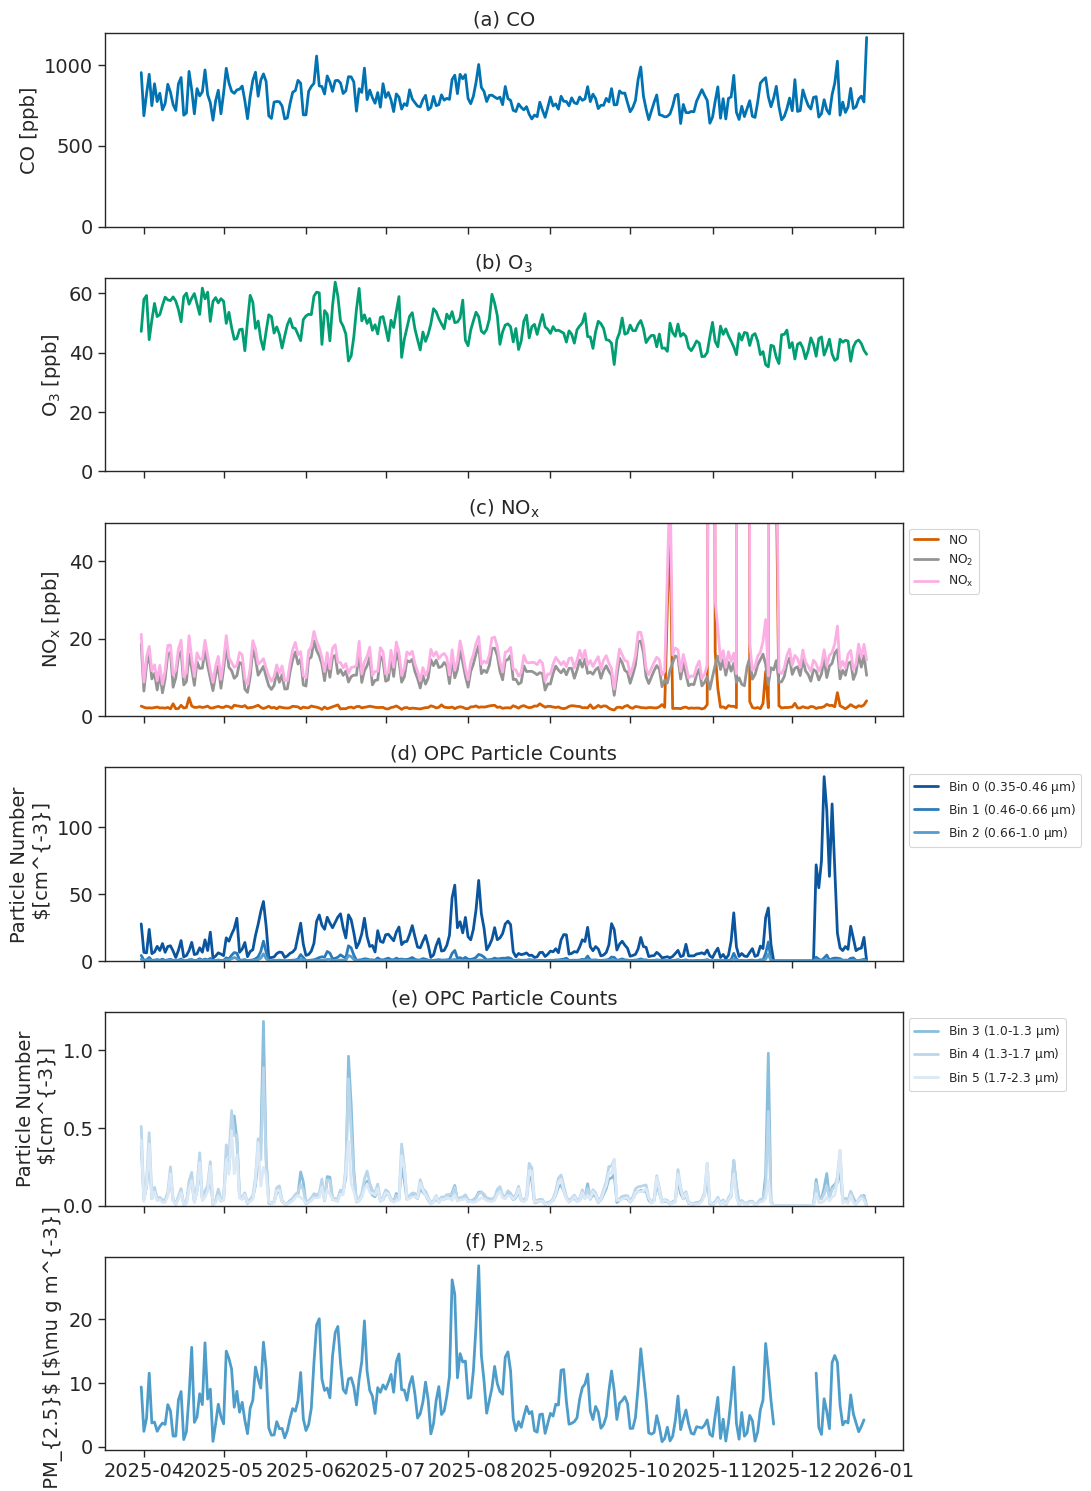

In [16]:
import os

# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(ts_day['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(0, None)

# plot the o3 on the second axis
ax[1].plot(ts_day['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(0, None)

#plot nox on the 2nd axis
ax[2].plot(ts_day['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(ts_day['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(ts_day['no2']+ts_day['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 50)


# plot the OPC bins on the 5th and 6th rows
ax[3].plot(ts_day['bin0'], lw=2, label=r'Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(ts_day['bin1'], lw=2, label=r'Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(ts_day['bin2'], lw=2, label=r'Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(ts_day['bin3'], lw=2, label=r'Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(ts_day['bin4'], lw=2, label=r'Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(ts_day['bin5'], lw=2, label=r'Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(ts_day['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
ax[5].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}]",fontsize=14)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(d) OPC Particle Counts", fontsize=14)
ax[4].set_title("(e) OPC Particle Counts", fontsize=14)
ax[5].set_title("(f) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

# force a tight layout
plt.tight_layout()

os.makedirs('MOD-00681', exist_ok=True)
fig.savefig('MOD-00681/timeseries_MOD-000681.png')

## Dirunal Plots

In [17]:
#taking daily average of ts. round to floor of the day
ts_hour = ts.groupby(ts['timestamp_local'].dt.floor('h')).agg(bin0 = ('bin0','mean'),
                                                  bin1 = ('bin1','mean'),
                                                  bin2 = ('bin2','mean'),
                                                  bin3 = ('bin3','mean'),
                                                  bin4 = ('bin4','mean'),
                                                  bin5 = ('bin5','mean'),
                                                  pm25 = ('pm25','mean'),
                                                  co = ('co','mean'),
                                                  o3 = ('o3','mean'),
                                                  no = ('no','mean'),
                                                  no2 = ('no2','mean'),
                                                  rh = ('rh','mean'),
                                                  temp = ('temp','mean')).reset_index()

ts_hour = ts_hour.set_index('timestamp_local')
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp
timestamp_local,,,,,,,,,,,,,
2025-03-31 20:00:00,28.992167,2.609400,1.145117,0.413050,0.590000,0.485150,12.744883,1085.495017,40.326450,1.989800,26.840717,80.846667,15.825000
2025-03-31 21:00:00,34.316100,4.568233,1.521733,0.478183,0.664867,0.589000,11.558950,1054.309383,40.841067,2.757617,23.562767,87.111667,15.686667
2025-03-31 22:00:00,31.949317,6.636000,1.740433,0.454700,0.564717,0.449733,9.043850,927.445750,45.553083,2.882700,15.229150,88.455000,16.136667
2025-03-31 23:00:00,15.635483,2.744550,0.751717,0.188200,0.219567,0.153883,4.057550,742.647267,61.705733,2.790750,8.545167,86.518333,15.983333
2025-04-01 00:00:00,16.636450,2.423633,0.665367,0.166800,0.205517,0.133583,4.426517,691.183967,64.155450,2.740117,5.725883,85.315000,15.560000


In [18]:
ts_hour['pm25_c'] = 2.111 + 0.298*ts_hour['pm25'] + 0.024*ts_hour['rh'] + 0.050*ts_hour['temp']
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
timestamp_local,,,,,,,,,,,,,,
2025-03-31 20:00:00,28.992167,2.609400,1.145117,0.413050,0.590000,0.485150,12.744883,1085.495017,40.326450,1.989800,26.840717,80.846667,15.825000,8.640545
2025-03-31 21:00:00,34.316100,4.568233,1.521733,0.478183,0.664867,0.589000,11.558950,1054.309383,40.841067,2.757617,23.562767,87.111667,15.686667,8.430580
2025-03-31 22:00:00,31.949317,6.636000,1.740433,0.454700,0.564717,0.449733,9.043850,927.445750,45.553083,2.882700,15.229150,88.455000,16.136667,7.735821
2025-03-31 23:00:00,15.635483,2.744550,0.751717,0.188200,0.219567,0.153883,4.057550,742.647267,61.705733,2.790750,8.545167,86.518333,15.983333,6.195757
2025-04-01 00:00:00,16.636450,2.423633,0.665367,0.166800,0.205517,0.133583,4.426517,691.183967,64.155450,2.740117,5.725883,85.315000,15.560000,6.255662


In [19]:
#prepping data
ts_hour['Hour'] = ts_hour.index.hour
ts_hour.head()

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour
timestamp_local,,,,,,,,,,,,,,,
2025-03-31 20:00:00,28.992167,2.609400,1.145117,0.413050,0.590000,0.485150,12.744883,1085.495017,40.326450,1.989800,26.840717,80.846667,15.825000,8.640545,20
2025-03-31 21:00:00,34.316100,4.568233,1.521733,0.478183,0.664867,0.589000,11.558950,1054.309383,40.841067,2.757617,23.562767,87.111667,15.686667,8.430580,21
2025-03-31 22:00:00,31.949317,6.636000,1.740433,0.454700,0.564717,0.449733,9.043850,927.445750,45.553083,2.882700,15.229150,88.455000,16.136667,7.735821,22
2025-03-31 23:00:00,15.635483,2.744550,0.751717,0.188200,0.219567,0.153883,4.057550,742.647267,61.705733,2.790750,8.545167,86.518333,15.983333,6.195757,23
2025-04-01 00:00:00,16.636450,2.423633,0.665367,0.166800,0.205517,0.133583,4.426517,691.183967,64.155450,2.740117,5.725883,85.315000,15.560000,6.255662,0


In [20]:
#groupping by hour and calculate the mean
diurnal_data = ts_hour.groupby('Hour').mean()
diurnal_data.index = diurnal_data.index.map(lambda x: "{:02d}:00".format(x))
diurnal_data

,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
Hour,,,,,,,,,,,,,,
00:00,15.669010,1.793150,0.525581,0.118150,0.119557,0.077738,6.865025,807.065544,46.547105,5.610050,12.414553,63.586707,16.351839,6.549937
01:00,16.089720,1.781948,0.503819,0.111180,0.115316,0.079772,6.844344,790.601028,45.843411,4.633637,12.439399,65.102814,16.105691,6.570565
02:00,16.005691,1.628631,0.450426,0.102677,0.111425,0.080469,6.630622,777.298539,45.261554,3.764713,11.812059,66.460039,15.737333,6.522533
03:00,16.414757,1.649317,0.441516,0.099386,0.109411,0.080998,6.416209,763.152405,44.471983,3.268224,11.663241,67.618286,15.377959,6.466335
04:00,16.949832,1.777948,0.500519,0.112999,0.116932,0.080976,6.311819,766.853550,43.558834,2.884412,11.964694,68.779172,15.085481,6.449438
05:00,17.193221,1.842159,0.525896,0.120816,0.125170,0.083707,6.400376,780.669547,42.363467,2.689338,12.282663,69.472984,14.882780,6.482248
06:00,16.827435,1.729988,0.497769,0.119120,0.126811,0.086049,6.502549,806.666371,41.439973,2.562411,12.259825,69.140822,14.743888,6.495657
07:00,16.677599,1.567243,0.431802,0.103081,0.117179,0.084331,6.889746,836.351511,41.751700,18.534964,11.152003,65.760862,15.865953,6.584315
08:00,15.837370,1.413495,0.380613,0.088871,0.104408,0.077355,7.185949,836.703208,42.947329,17.666625,9.438302,60.303927,17.419277,6.617606


<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:27: SyntaxWarning: invalid escape sequence '\m'
<>:28: SyntaxWarning: invalid escape sequence '\m'
<>:34: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:36: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-217/4044509663.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipython-input-217/4044509663.py:27: SyntaxWarning: invalid escape sequence '\m'
  ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette(

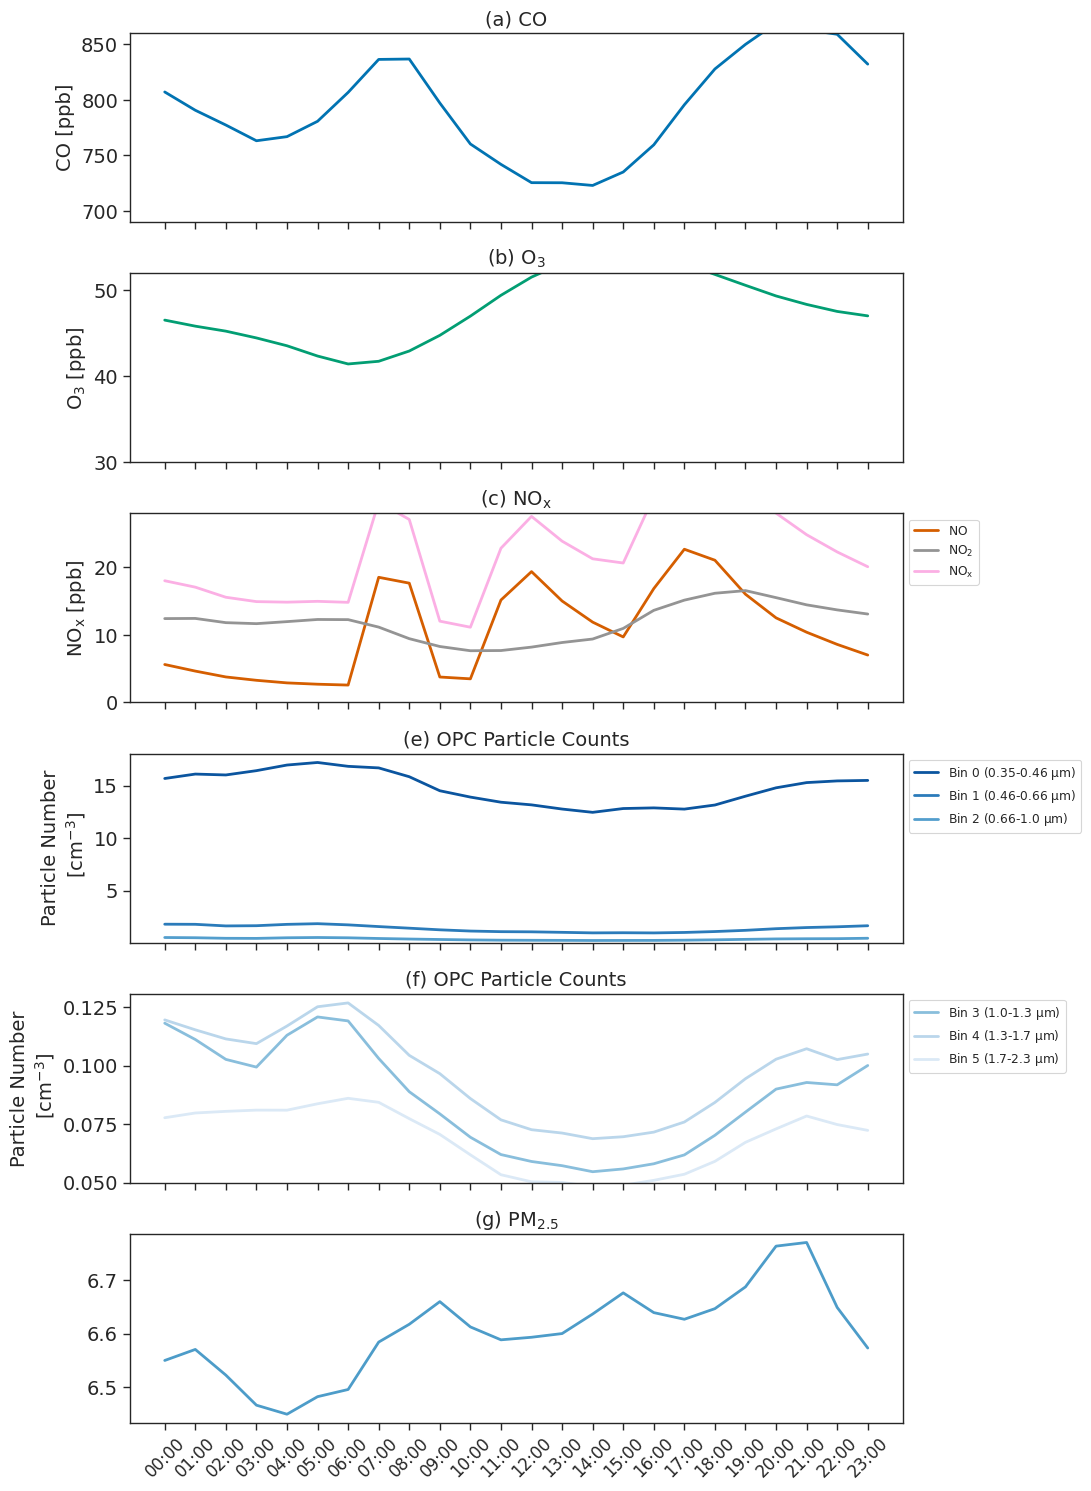

In [21]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=1, figsize=(11, 15), sharex=True)

# grab the current color palette
cmap = sns.color_palette()

# plot the CO data and label the axis
ax[0].plot(diurnal_data['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
ax[0].set_ylabel("CO [ppb]", fontsize=14)
ax[0].set_ylim(690, 860)

# plot the o3 on the first axis
ax[1].plot(diurnal_data['o3'], lw=2, label="$O_3$", color=cmap[2])
ax[1].set_ylabel("$O_3$ [ppb]", fontsize=14)
ax[1].set_ylim(30, 52)

#plot nox on the 2nd axis
ax[2].plot(diurnal_data['no'], lw=2, label="$NO$", color=cmap[3])
ax[2].plot(diurnal_data['no2'], lw=2, label="$NO_2$", color=cmap[7])
ax[2].plot(diurnal_data['no2']+diurnal_data['no'], lw=2, label="$NO_x$", color=cmap[6])
ax[2].set_ylabel("$NO_x$ [ppb]", fontsize=14)
ax[2].legend(fontsize = 14)
ax[2].set_ylim(0, 28)

# plot the OPC bins on the 3rd and 4th rows
ax[3].plot(diurnal_data['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
ax[3].plot(diurnal_data['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
ax[3].plot(diurnal_data['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
ax[3].set(ylim=(0.05, None))
ax[3].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[3].legend(fontsize = 14)


ax[4].plot(diurnal_data['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
ax[4].plot(diurnal_data['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
ax[4].plot(diurnal_data['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
ax[4].set(ylim=(0.05, None))
ax[4].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=14)
ax[4].legend(fontsize = 14)


#plot pm25 on the 6th row
ax[5].plot(diurnal_data['pm25_c'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)

# set titles for each panel
ax[0].set_title("(a) CO", fontsize=14)
ax[1].set_title("(b) $O_3$", fontsize=14)
ax[2].set_title("(c) $NO_x$", fontsize=14)
ax[3].set_title("(e) OPC Particle Counts", fontsize=14)
ax[4].set_title("(f) OPC Particle Counts", fontsize=14)
ax[5].set_title("(g) $PM_{2.5}$", fontsize=14)

ax[0].tick_params(axis='both', which='major', labelsize=14)
ax[1].tick_params(axis='both', which='major', labelsize=14)
ax[2].tick_params(axis='both', which='major', labelsize=14)
ax[3].tick_params(axis='both', which='major', labelsize=14)
ax[4].tick_params(axis='both', which='major', labelsize=14)
ax[5].tick_params(axis='both', which='major', labelsize=14)
ax[5].locator_params(axis='y', nbins=4)
ax[4].locator_params(axis='y', nbins=4)
ax[3].locator_params(axis='y', nbins=4)
ax[2].locator_params(axis='y', nbins=4)
ax[1].locator_params(axis='y', nbins=4)
ax[0].locator_params(axis='y', nbins=4)

# set x as hours
ax[5].set_xticks(range(24))
ax[5].set_xticklabels([f"{h:02d}:00" for h in range(24)], rotation=45)

# move legends
sns.move_legend(ax[2], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[3], "upper left", bbox_to_anchor=(1, 1))
sns.move_legend(ax[4], "upper left", bbox_to_anchor=(1, 1))

plt.xticks(range(0, 24), size = 12)
plt.xticks(rotation=45)

# force a tight layout
plt.tight_layout()

fig.savefig('MOD-00681/dirunal_MOD-000681_allfeatures.png')

## Diurnal by Season

In [22]:
def month_to_season(month):
    if 3 <= month <= 5:
        return 'Spring'
    elif 6 <= month <= 8:
        return 'Summer'
    elif 9 <= month <= 11:
        return 'Autumn'
    else:
        return 'Winter'

In [23]:
ts_hour = ts_hour.reset_index()

In [24]:
#prepping data
ts_hour['Season'] = ts_hour['timestamp_local'].dt.month.apply(month_to_season)
ts_hour.head()

,timestamp_local,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c,Hour,Season
0,2025-03-31 20:00:00,28.992167,2.609400,1.145117,0.413050,0.590000,0.485150,12.744883,1085.495017,40.326450,1.989800,26.840717,80.846667,15.825000,8.640545,20,Spring
1,2025-03-31 21:00:00,34.316100,4.568233,1.521733,0.478183,0.664867,0.589000,11.558950,1054.309383,40.841067,2.757617,23.562767,87.111667,15.686667,8.430580,21,Spring
2,2025-03-31 22:00:00,31.949317,6.636000,1.740433,0.454700,0.564717,0.449733,9.043850,927.445750,45.553083,2.882700,15.229150,88.455000,16.136667,7.735821,22,Spring
3,2025-03-31 23:00:00,15.635483,2.744550,0.751717,0.188200,0.219567,0.153883,4.057550,742.647267,61.705733,2.790750,8.545167,86.518333,15.983333,6.195757,23,Spring
4,2025-04-01 00:00:00,16.636450,2.423633,0.665367,0.166800,0.205517,0.133583,4.426517,691.183967,64.155450,2.740117,5.725883,85.315000,15.560000,6.255662,0,Spring


In [25]:
grouped_by_season_hour = ts_hour.drop(columns='timestamp_local').groupby(['Season', 'Hour']).mean()
grouped_by_season_hour

bin0      bin1      bin2      bin3      bin4      bin5  \
Season Hour                                                                
Autumn 0      8.083870  1.016265  0.351840  0.085180  0.094587  0.067000   
       1      8.634885  0.896662  0.279561  0.066114  0.079681  0.065308   
       2      8.957048  0.891010  0.277442  0.067632  0.082230  0.068612   
       3      9.368129  0.948913  0.288501  0.069670  0.084172  0.070684   
       4      9.990661  1.152364  0.352206  0.081326  0.088075  0.067476   
...                ...       ...       ...       ...       ...       ...   
Winter 19    30.505670  0.872508  0.219509  0.049773  0.047343  0.032220   
       20    30.595967  1.009259  0.245955  0.055025  0.050598  0.034388   
       21    32.266276  0.958850  0.239340  0.055284  0.054826  0.037285   
       22    34.823911  1.123211  0.271688  0.062820  0.060846  0.040809   
       23    38.515609  1.845345  0.430534  0.095988  0.081756  0.049878   

                 pm25          co         o3         no        no2         rh  \
Season Hour                                                                     
Autumn 0     5.008367  779.319394  44.099102  12.718040  12.211124  62.768281   
       1     5.113244  769.925019  43.334576   9.865456  13.258973  65.130238   
       2     5.038937  754.950070  42.842060   7.150872  12.459466  66.940684   
       3     5.016203  741.704936  42.077413   5.715380  11.774298  68.185173   
       4     4.961479  751.144872  41.334509   4.497833  12.375387  69.655152   
...               ...         ...        ...        ...        ...        ...   
Winter 19    5.840121  786.166061  41.188890   2.451755  15.499179  56.890740   
       20    6.323320  787.909983  41.239726   2.531035  14.971176  57.633969   
       21    6.141751  781.386547  41.347879   2.460247  13.497914  57.955275   
       22    6.385597  766.934183  41.429484   2.473057  12.813816  59.310719   
       23    7.024226  781.086553  40.964639   2.511007  12.650877  61.077983   

                  temp    pm25_c  
Season Hour                       
Autumn 0     15.079984  5.903391  
       1     14.822530  5.983880  
       2     14.445691  5.989376  
       3     14.102074  5.996476  
       4     13.819265  6.002093  
...                ...       ...  
Winter 19     1.729805  5.345522  
       20     1.390958  5.487334  
       21     1.215126  5.433485  
       22     1.047077  5.530526  
       23     0.772595  5.756489  

[96 rows x 14 columns]

In [26]:
grouped_by_season_hour = grouped_by_season_hour.reset_index()
grouped_by_season_hour

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
0,Autumn,0,8.083870,1.016265,0.351840,0.085180,0.094587,0.067000,5.008367,779.319394,44.099102,12.718040,12.211124,62.768281,15.079984,5.903391
1,Autumn,1,8.634885,0.896662,0.279561,0.066114,0.079681,0.065308,5.113244,769.925019,43.334576,9.865456,13.258973,65.130238,14.822530,5.983880
2,Autumn,2,8.957048,0.891010,0.277442,0.067632,0.082230,0.068612,5.038937,754.950070,42.842060,7.150872,12.459466,66.940684,14.445691,5.989376
3,Autumn,3,9.368129,0.948913,0.288501,0.069670,0.084172,0.070684,5.016203,741.704936,42.077413,5.715380,11.774298,68.185173,14.102074,5.996476
4,Autumn,4,9.990661,1.152364,0.352206,0.081326,0.088075,0.067476,4.961479,751.144872,41.334509,4.497833,12.375387,69.655152,13.819265,6.002093
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,Winter,19,30.505670,0.872508,0.219509,0.049773,0.047343,0.032220,5.840121,786.166061,41.188890,2.451755,15.499179,56.890740,1.729805,5.345522
92,Winter,20,30.595967,1.009259,0.245955,0.055025,0.050598,0.034388,6.323320,787.909983,41.239726,2.531035,14.971176,57.633969,1.390958,5.487334
93,Winter,21,32.266276,0.958850,0.239340,0.055284,0.054826,0.037285,6.141751,781.386547,41.347879,2.460247,13.497914,57.955275,1.215126,5.433485
94,Winter,22,34.823911,1.123211,0.271688,0.062820,0.060846,0.040809,6.385597,766.934183,41.429484,2.473057,12.813816,59.310719,1.047077,5.530526


In [27]:
autumn_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Autumn']
winter_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Winter']
spring_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Spring']
summer_diurnal = grouped_by_season_hour[grouped_by_season_hour['Season'] == 'Summer']

autumn_diurnal.index = autumn_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
winter_diurnal.index = winter_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
spring_diurnal.index = spring_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))
summer_diurnal.index = summer_diurnal.index.map(lambda x: "{:02d}:00".format(x%24))

In [28]:
autumn_diurnal

,Season,Hour,bin0,bin1,bin2,bin3,bin4,bin5,pm25,co,o3,no,no2,rh,temp,pm25_c
00:00,Autumn,0,8.083870,1.016265,0.351840,0.085180,0.094587,0.067000,5.008367,779.319394,44.099102,12.718040,12.211124,62.768281,15.079984,5.903391
01:00,Autumn,1,8.634885,0.896662,0.279561,0.066114,0.079681,0.065308,5.113244,769.925019,43.334576,9.865456,13.258973,65.130238,14.822530,5.983880
02:00,Autumn,2,8.957048,0.891010,0.277442,0.067632,0.082230,0.068612,5.038937,754.950070,42.842060,7.150872,12.459466,66.940684,14.445691,5.989376
03:00,Autumn,3,9.368129,0.948913,0.288501,0.069670,0.084172,0.070684,5.016203,741.704936,42.077413,5.715380,11.774298,68.185173,14.102074,5.996476
04:00,Autumn,4,9.990661,1.152364,0.352206,0.081326,0.088075,0.067476,4.961479,751.144872,41.334509,4.497833,12.375387,69.655152,13.819265,6.002093
05:00,Autumn,5,10.727627,1.436919,0.435071,0.094564,0.094577,0.066526,4.969792,760.633166,40.343725,3.838040,12.299986,70.514616,13.634915,6.017303
06:00,Autumn,6,10.639973,1.339855,0.410652,0.089884,0.088702,0.062130,4.913565,784.955936,39.030576,3.142658,12.135956,70.853412,12.927368,5.967402
07:00,Autumn,7,10.628837,1.133077,0.335756,0.075984,0.083681,0.062139,5.270644,827.392785,39.488582,53.688911,11.889546,68.983932,13.835568,6.075254
08:00,Autumn,8,9.528793,0.877603,0.269688,0.064846,0.077779,0.058400,5.561647,825.116152,40.676745,49.664770,9.158138,62.667258,15.263618,6.080040
09:00,Autumn,9,8.833666,0.791180,0.257697,0.063812,0.077831,0.057355,5.757819,784.458002,42.310480,5.842055,8.455179,56.835401,17.125711,6.089042


In [29]:
seasons_order = [winter_diurnal, spring_diurnal, summer_diurnal, autumn_diurnal]

<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:41: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\m'
<>:48: SyntaxWarning: invalid escape sequence '\m'
<>:49: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipython-input-217/3315571929.py:40: SyntaxWarning: invalid escape sequence '\m'
  ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
/tmp/ipython-input-217/3315571929.py:41: SyntaxWarning: invalid escape sequen

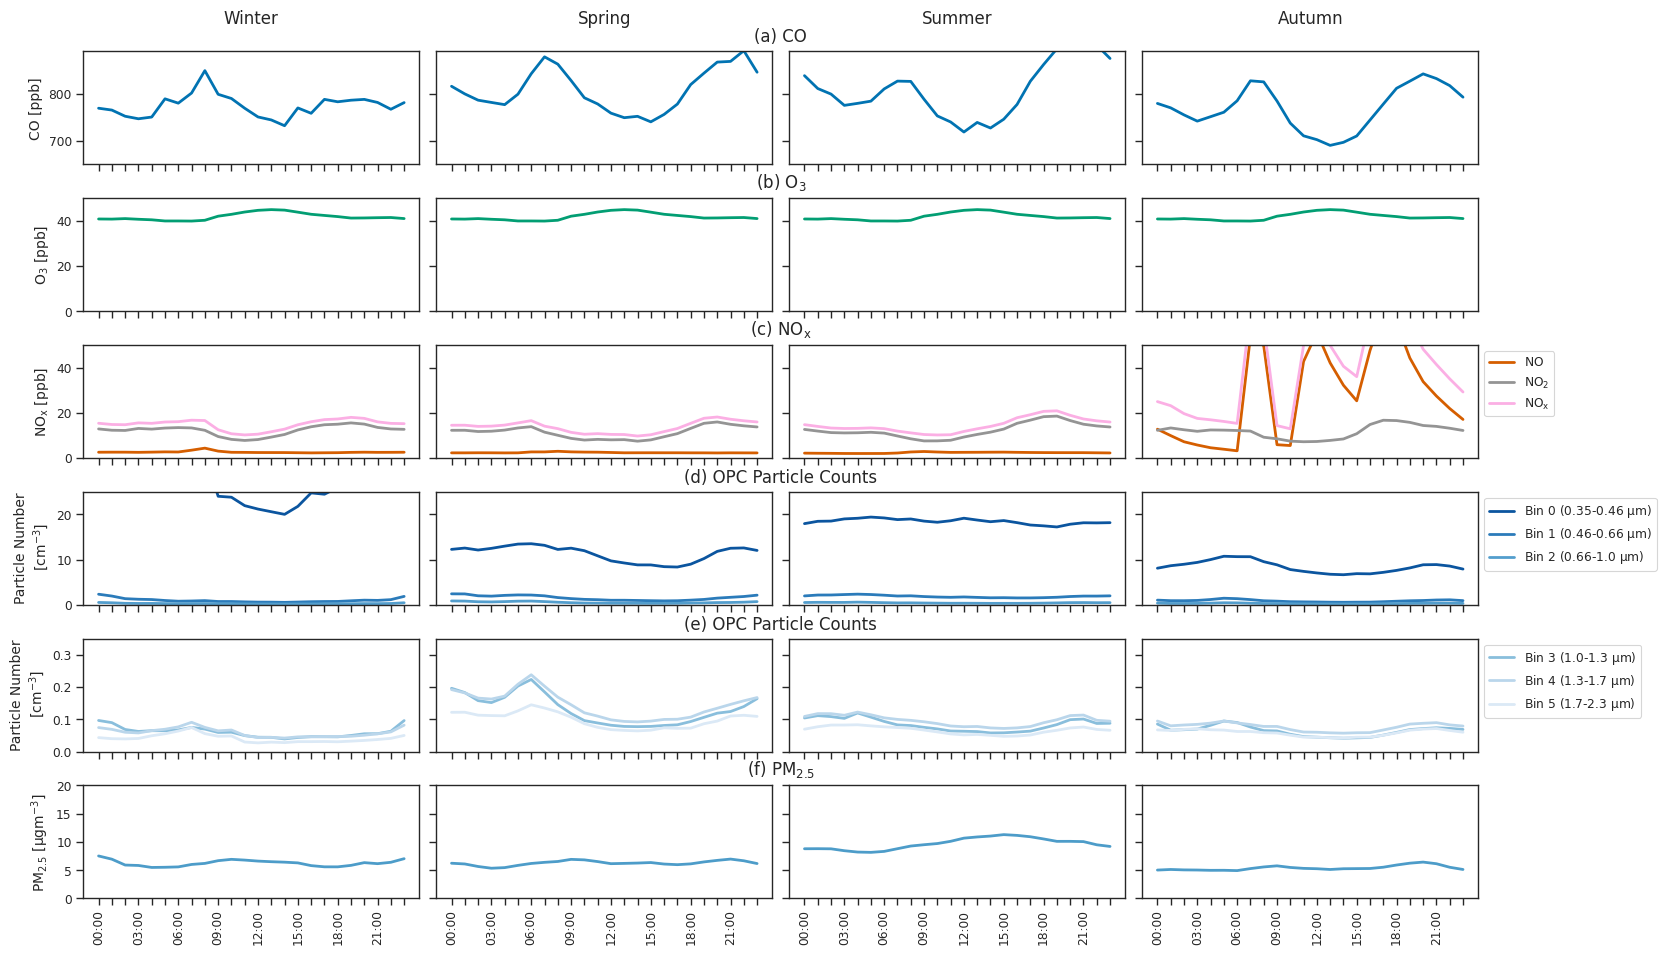

In [30]:
# set up the matplotlib figure
fig, ax = plt.subplots(nrows=6, ncols=4, figsize=(18,11), sharex=True)
plt.subplots_adjust(hspace = 0.3, wspace = 0.05)

# grab the current color palette
cmap = sns.color_palette()

#iterate through seasons
for i in range(len(seasons_order)):

    #set ax column labels as season
    ax[0,0].set_title("Winter", fontsize=12, pad = 20)
    ax[0,1].set_title("Spring", fontsize=12, pad = 20)
    ax[0,2].set_title("Summer", fontsize=12, pad = 20)
    ax[0,3].set_title("Autumn", fontsize=12, pad = 20)

    # plot the CO data and label the axis
    ax[0,0].set_ylabel("CO [ppb]", fontsize=10)
    ax[0,i].plot(seasons_order[i]['co'], lw=2, label="$CO$", color=sns.color_palette()[0])
    ax[0,i].set_ylim(650, 890)
    ax[0,i].set_xticks(range(0, 2))
    ax[0,i].set_xticks(seasons_order[i].index)

    # plot the o3 on the second axis
    ax[1,0].set_ylabel("$O_3$ [ppb]", fontsize=10)
    ax[1,i].plot(winter_diurnal['o3'], lw=2, label="$O_3$", color=cmap[2])
    ax[1,i].set_ylim(0, 50)

    #plot nox on the 3rd axis
    ax[2,0].set_ylabel("$NO_x$ [ppb]", fontsize=10)
    ax[2,i].plot(seasons_order[i]['no'], lw=2, label="$NO$", color=cmap[3])
    ax[2,i].plot(seasons_order[i]['no2'], lw=2, label="$NO_2$", color=cmap[7])
    ax[2,i].plot(seasons_order[i]['no2']+seasons_order[i]['no'], lw=2, label="$NO_x$", color=cmap[6])
    ax[2,i].set_ylim(0, 50)
    ax[2,3].legend(fontsize = 14)
    sns.move_legend(ax[2,3], "upper left", bbox_to_anchor=(1, 1))

    # plot the OPC bins on the 4th and 5th rows
    ax[3,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[3,i].plot(seasons_order[i]['bin0'], lw=2, label='Bin 0 (0.35-0.46 $\mu m$)', color=sns.color_palette("Blues_r", 6)[0])
    ax[3,i].plot(seasons_order[i]['bin1'], lw=2, label='Bin 1 (0.46-0.66 $\mu m$)', color=sns.color_palette("Blues_r", 6)[1])
    ax[3,i].plot(seasons_order[i]['bin2'], lw=2, label='Bin 2 (0.66-1.0 $\mu m$)', color=sns.color_palette("Blues_r", 6)[2])
    ax[3,i].set(ylim=(0, 25))
    ax[3,3].legend(fontsize = 14)
    sns.move_legend(ax[3,3], "upper left", bbox_to_anchor=(1, 1))

    ax[4,0].set_ylabel("Particle Number\n $[cm^{-3}]$", fontsize=10)
    ax[4,i].plot(seasons_order[i]['bin3'], lw=2, label='Bin 3 (1.0-1.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[3])
    ax[4,i].plot(seasons_order[i]['bin4'], lw=2, label='Bin 4 (1.3-1.7 $\mu m$)', color=sns.color_palette("Blues_r", 6)[4])
    ax[4,i].plot(seasons_order[i]['bin5'], lw=2, label='Bin 5 (1.7-2.3 $\mu m$)', color=sns.color_palette("Blues_r", 6)[5])
    ax[4,i].set(ylim=(0, 0.35))
    ax[4,3].legend(fontsize = 14)
    sns.move_legend(ax[4,3], "upper left", bbox_to_anchor=(1, 1))

    #plot pm25 on the 6th row
    ax[5,0].set_ylabel("$PM_{2.5}$ [$\mu g m^{-3}$]",fontsize=10)
    ax[5,i].plot(seasons_order[i]['pm25'], lw=2, label = '$PM_{2.5}$ as reported', color=sns.color_palette()[0], alpha = 0.7)
    ax[5,i].set(ylim=(0, 20))
    ax[5,i].set_xticklabels(['00:00','','','03:00','','','06:00','','','09:00','','','12:00','','','15:00','','','18:00','','','21:00','',''], rotation=90)

    #remove subplot y ticks for subplots beyond winter
    if i>0:
        for j in range(6):
            ax[j,i].set_yticklabels([])

    # set titles for each panel
    row_titles = [
    "(a) CO",
    "(b) $O_3$",
    "(c) $NO_x$",
    "(d) OPC Particle Counts",
    "(e) OPC Particle Counts",
    "(f) $PM_{2.5}$"
]

for r, title in enumerate(row_titles):

    # left and right subplot positions
    left = ax[r,0].get_position()
    right = ax[r,-1].get_position()

    # horizontal center between first and last column
    x_center = (left.x0 + right.x1) / 2

    # slightly above the row
    y_top = left.y1 + 0.005

    fig.text(
        x_center,
        y_top,
        title,
        ha='center',
        va='bottom',
        fontsize=12
    )

fig.savefig('MOD-00681/diurnal_by_season_MOD-000681.png')